## 로지스틱 회귀 모형 (VIF 10)

findfont: Font family ['NanumGothic'] not found. Falling back to DejaVu Sans.


Train shape : 32,268행 × 260열
Test  shape : 7,664행 × 260열
사용 피처   : 60개

Train : 32,268건  (정상 31,087 / 부실 1,181)
Test  : 7,664건  (정상 7,346 / 부실 318)
불균형 비율 : 26.3:1

  교차검증 결과 (5-Fold Stratified KFold)
  accuracy     | Train 0.8595 ± 0.0011 | Val 0.8589 ± 0.0030
  roc_auc      | Train 0.9369 ± 0.0007 | Val 0.9320 ± 0.0027
  f1           | Train 0.3158 ± 0.0018 | Val 0.3093 ± 0.0043
  precision    | Train 0.1921 ± 0.0013 | Val 0.1884 ± 0.0033
  recall       | Train 0.8859 ± 0.0036 | Val 0.8628 ± 0.0061

  Test Set 최종 성과
  Accuracy  : 0.8428
  ROC-AUC   : 0.9108
  PR-AUC    : 0.2897
  F1 Score  : 0.3055
  Precision : 0.1870
  Recall    : 0.8333

[Classification Report]
              precision    recall  f1-score   support

       정상(0)       0.99      0.84      0.91      7346
       부실(1)       0.19      0.83      0.31       318

    accuracy                           0.84      7664
   macro avg       0.59      0.84      0.61      7664
weighted avg       0.96      0.84      0.89      7664

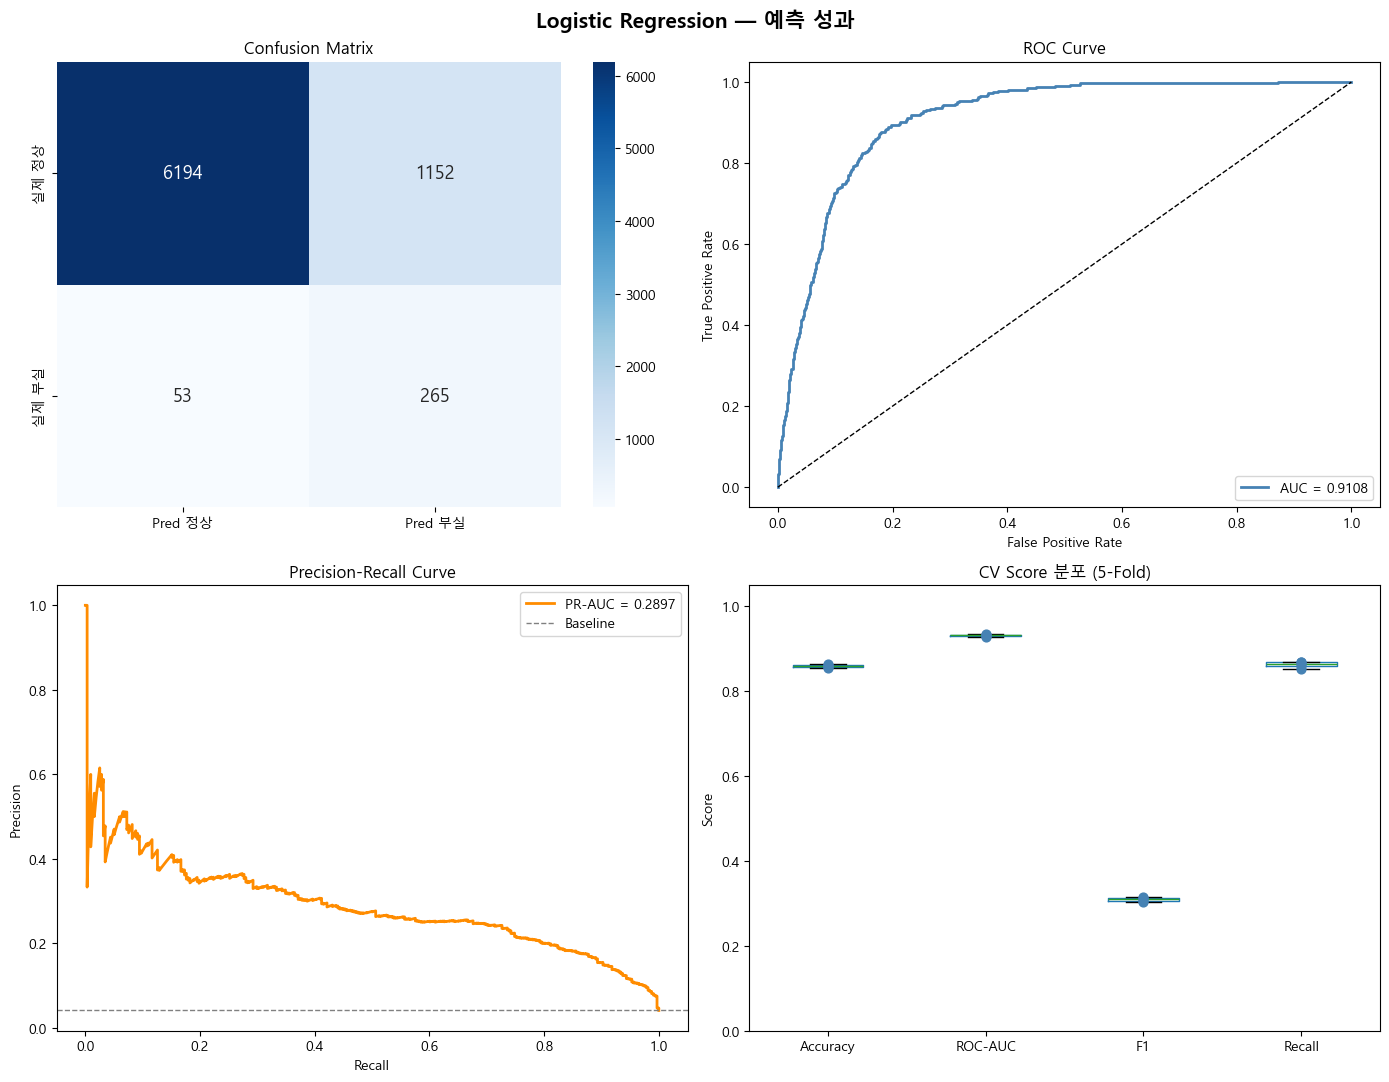

시각화 저장 → logistic_regression_results.png

[피처 중요도 Top 20]
               feature      coef
         영업CF_총부채_diff -1.512186
            ROIC_ratio -1.361266
           현금ROA_ratio  0.948976
         EBITDA마진_diff -0.770741
          금융비용부담률_diff  0.748688
          영업이익률변화_diff  0.717371
          투하자본회전율_diff  0.576440
                 부채증가율 -0.390100
                총자산회전율 -0.390008
비유동자산회전율_diff_industry -0.379114
          유형자산비율_ratio -0.348598
                순차입금비율  0.336894
            현금비율_ratio -0.331616
          영업이익증가율_diff -0.311966
        매출채권회수기간_ratio -0.301890
비유동장기적합률_diff_industry  0.299808
         유형자산부채비율_diff  0.293540
            자본잠식률_diff -0.267904
          장기부채비율_ratio -0.243464
           매출액증가율_diff  0.239458


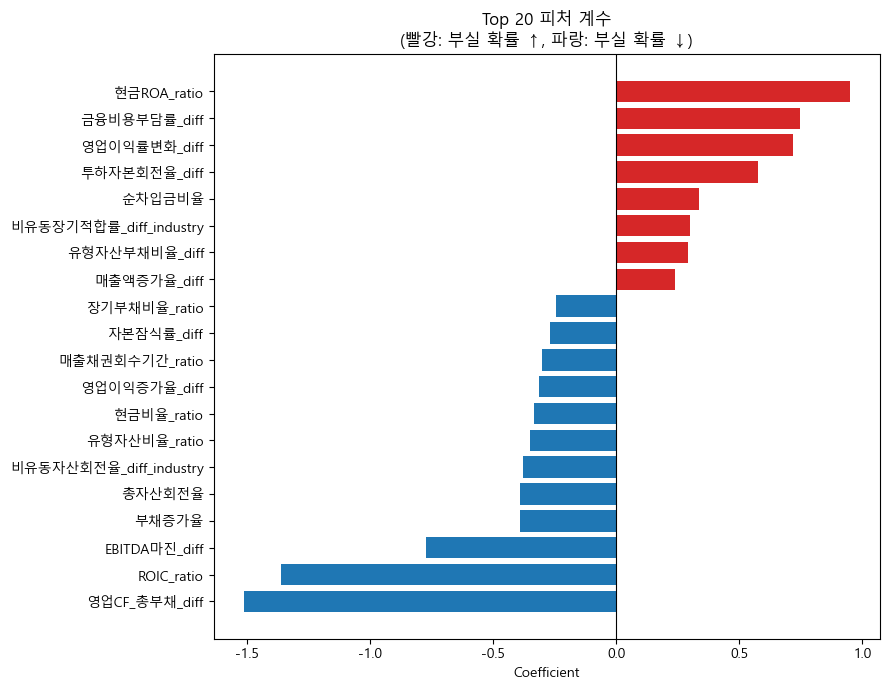

피처 중요도 저장 → logistic_feature_importance.png


In [1]:
import pandas as pd
import numpy as np
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import StratifiedKFold, cross_validate
from sklearn.metrics import (
    accuracy_score, roc_auc_score, f1_score, precision_score, recall_score,
    classification_report, confusion_matrix, roc_curve,
    precision_recall_curve, average_precision_score
)
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# ── 한글 폰트 ───────────────────────────────
import matplotlib
matplotlib.rcParams['axes.unicode_minus'] = False
for family in ['NanumGothic', 'Malgun Gothic', 'AppleGothic']:
    if fm.findfont(fm.FontProperties(family=family)) != fm.findfont(fm.FontProperties()):
        matplotlib.rc('font', family=family)
        break

# ────────────────────────────────────────────
# 0. 설정값
# ────────────────────────────────────────────
TRAIN_PATH   = r"C:\유비온프로젝트2\corporate-bankruptcy\혜원\10,11,12번 [Train] .parquet"
TEST_PATH    = r"C:\유비온프로젝트2\corporate-bankruptcy\혜원\10,11,12번 [Test].parquet"
FEATURE_PATH = r"C:\유비온프로젝트2\corporate-bankruptcy\혜원\13번. 최종피처.parquet"        # 최종 피처 60개 목록
TARGET_COL   = "부실라벨_ICR3년"
CV_FOLDS     = 5
RANDOM_STATE = 42
THRESHOLD    = 0.5                             # 분류 임계값

# 피처에서 제외할 식별자 컬럼
EXCLUDE_COLS = [
    '사업자등록번호', '회계년도', '회사명',
    '통계청 한국표준산업분류 코드 11차(대분류)',
    '통계청 한국표준산업분류 11차(중분류)',
    'M코드', '빅4감사',
]

# ────────────────────────────────────────────
# 1. 데이터 로드
# ────────────────────────────────────────────
train    = pd.read_parquet(TRAIN_PATH)
test     = pd.read_parquet(TEST_PATH)
features = pd.read_parquet(FEATURE_PATH)['final_feature'].tolist()

print(f"Train shape : {train.shape[0]:,}행 × {train.shape[1]}열")
print(f"Test  shape : {test.shape[0]:,}행 × {test.shape[1]}열")
print(f"사용 피처   : {len(features)}개")

# ────────────────────────────────────────────
# 2. 피처 / 타겟 분리 (60개 피처만 사용)
# ────────────────────────────────────────────
missing = [f for f in features if f not in train.columns]
if missing:
    print(f"⚠️  Train에 없는 피처: {missing}")

use_features = [f for f in features if f in train.columns]

X_train = train[use_features]
y_train = train[TARGET_COL]
X_test  = test[use_features]
y_test  = test[TARGET_COL]

print(f"\nTrain : {len(X_train):,}건  (정상 {(y_train==0).sum():,} / 부실 {(y_train==1).sum():,})")
print(f"Test  : {len(X_test):,}건  (정상 {(y_test==0).sum():,} / 부실 {(y_test==1).sum():,})")
print(f"불균형 비율 : {(y_train==0).sum()/(y_train==1).sum():.1f}:1")

# ────────────────────────────────────────────
# 3. 모델 정의
#    - 이상치 처리·스케일링 이미 완료된 데이터이므로 스케일링 생략
#    - class_weight='balanced' : 불균형 대응
# ────────────────────────────────────────────
model = LogisticRegression(
    penalty='l2',
    C=1.0,
    solver='lbfgs',
    class_weight='balanced',
    max_iter=1000,
    random_state=RANDOM_STATE
)

# ────────────────────────────────────────────
# 4. 교차검증 (Train 기준, Stratified K-Fold)
# ────────────────────────────────────────────
skf = StratifiedKFold(n_splits=CV_FOLDS, shuffle=True, random_state=RANDOM_STATE)

cv_results = cross_validate(
    model, X_train, y_train,
    cv=skf,
    scoring=['accuracy', 'roc_auc', 'f1', 'precision', 'recall'],
    return_train_score=True
)

print("\n" + "="*62)
print(f"  교차검증 결과 ({CV_FOLDS}-Fold Stratified KFold)")
print("="*62)
for m in ['accuracy', 'roc_auc', 'f1', 'precision', 'recall']:
    tr = cv_results[f'train_{m}']
    va = cv_results[f'test_{m}']
    print(f"  {m:12s} | Train {tr.mean():.4f} ± {tr.std():.4f}"
          f" | Val {va.mean():.4f} ± {va.std():.4f}")

# ────────────────────────────────────────────
# 5. 전체 Train으로 최종 학습 → Test 평가
# ────────────────────────────────────────────
model.fit(X_train, y_train)

y_prob = model.predict_proba(X_test)[:, 1]
y_pred = (y_prob >= THRESHOLD).astype(int)

print("\n" + "="*62)
print("  Test Set 최종 성과")
print("="*62)
print(f"  Accuracy  : {accuracy_score(y_test, y_pred):.4f}")
print(f"  ROC-AUC   : {roc_auc_score(y_test, y_prob):.4f}")
print(f"  PR-AUC    : {average_precision_score(y_test, y_prob):.4f}")
print(f"  F1 Score  : {f1_score(y_test, y_pred):.4f}")
print(f"  Precision : {precision_score(y_test, y_pred):.4f}")
print(f"  Recall    : {recall_score(y_test, y_pred):.4f}")
print(f"\n[Classification Report]")
print(classification_report(y_test, y_pred, target_names=['정상(0)', '부실(1)']))

# ────────────────────────────────────────────
# 6. 시각화 (2×2)
# ────────────────────────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(14, 11))
fig.suptitle("Logistic Regression — 예측 성과", fontsize=15, fontweight='bold')

# (A) Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0][0],
            xticklabels=['Pred 정상', 'Pred 부실'],
            yticklabels=['실제 정상', '실제 부실'],
            annot_kws={'size': 13})
axes[0][0].set_title("Confusion Matrix")

# (B) ROC Curve
fpr, tpr, _ = roc_curve(y_test, y_prob)
axes[0][1].plot(fpr, tpr, color='steelblue', lw=2,
                label=f'AUC = {roc_auc_score(y_test, y_prob):.4f}')
axes[0][1].plot([0,1],[0,1], 'k--', lw=1)
axes[0][1].set_title("ROC Curve")
axes[0][1].set_xlabel("False Positive Rate")
axes[0][1].set_ylabel("True Positive Rate")
axes[0][1].legend(loc='lower right')

# (C) Precision-Recall Curve
prec, rec, _ = precision_recall_curve(y_test, y_prob)
pr_auc = average_precision_score(y_test, y_prob)
axes[1][0].plot(rec, prec, color='darkorange', lw=2, label=f'PR-AUC = {pr_auc:.4f}')
axes[1][0].axhline((y_test==1).mean(), color='gray', linestyle='--', lw=1, label='Baseline')
axes[1][0].set_title("Precision-Recall Curve")
axes[1][0].set_xlabel("Recall")
axes[1][0].set_ylabel("Precision")
axes[1][0].legend(loc='upper right')

# (D) CV Score 분포
cv_df = pd.DataFrame({
    'Accuracy' : cv_results['test_accuracy'],
    'ROC-AUC'  : cv_results['test_roc_auc'],
    'F1'       : cv_results['test_f1'],
    'Recall'   : cv_results['test_recall'],
})
cv_df.boxplot(ax=axes[1][1], grid=False)
for i, col in enumerate(cv_df.columns, 1):
    axes[1][1].scatter([i]*CV_FOLDS, cv_df[col], color='steelblue', zorder=5, s=40)
axes[1][1].set_title(f"CV Score 분포 ({CV_FOLDS}-Fold)")
axes[1][1].set_ylabel("Score")
axes[1][1].set_ylim(0, 1.05)

plt.tight_layout()
plt.savefig("logistic_regression_results.png", dpi=150, bbox_inches='tight')
plt.show()
print("시각화 저장 → logistic_regression_results.png")

# ────────────────────────────────────────────
# 7. 피처 중요도 (계수 절댓값 Top 20)
# ────────────────────────────────────────────
coef_df = pd.DataFrame({
    'feature'  : use_features,
    'coef'     : model.coef_[0],
    'abs_coef' : np.abs(model.coef_[0])
}).sort_values('abs_coef', ascending=False).reset_index(drop=True)

print("\n[피처 중요도 Top 20]")
print(coef_df.head(20)[['feature', 'coef']].to_string(index=False))

top20  = coef_df.head(20).sort_values('coef')
colors = ['#d62728' if c > 0 else '#1f77b4' for c in top20['coef']]

plt.figure(figsize=(9, 7))
plt.barh(top20['feature'], top20['coef'], color=colors)
plt.axvline(0, color='black', lw=0.8)
plt.title("Top 20 피처 계수\n(빨강: 부실 확률 ↑, 파랑: 부실 확률 ↓)")
plt.xlabel("Coefficient")
plt.tight_layout()
plt.savefig("logistic_feature_importance.png", dpi=150, bbox_inches='tight')
plt.show()
print("피처 중요도 저장 → logistic_feature_importance.png")